Используйте те же данные из файла exp_metrics.csv, что и в воркшопе.

1) Оцените при помощи бутстрепа 95%-ный доверительный интервал для медианы времени (sum_time) в группе В. Каковы получились его границы?
2) Проверьте, есть ли статистически значимое различие в 90%-ном процентиле (квантиль 0.9) времени (sum_time) между группами А и В на уровне значимости 1% (по 99%-ному доверительному интервалу).

В качестве результата к первому заданию после вычислений должны быть обозначены границы доверительного интервала или картинка с бутстреп-распределением и указанием границ. Во втором задании также предоставьте вычисления и графики, а также вывод о том, есть ли статистически значимые различия, объясните, почему так произошло.

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import bootstrap
import matplotlib.pyplot as plt

data = pd.read_csv('exp_metrics.csv')

In [11]:
group_B = data[data['group'] == 'B']['sum_time']
#параметры
n_resamples = 10000
confidence_level = 0.95

def median_func(data):
    return np.median(data)

#бутстреп
result = bootstrap(
    (group_b,),
    median_func,
    confidence_level=confidence_level,
    n_resamples=n_resamples
)

print(f"95% доверительный интервал для медианы:")
print(f"Нижняя граница: {result.confidence_interval.low:.2f} минут")
print(f"Верхняя граница: {result.confidence_interval.high:.2f} минут")

95% доверительный интервал для медианы:
Нижняя граница: 135.57 минут
Верхняя граница: 137.75 минут


Это означает, что с вероятностью 95% можно утверждать, что истинная медиана времени в группе В находится в диапазоне от 135.55 минут до 137.73 минут. Это значит что половина пользователей в группе В тратит на взаимодействие менее 137,73 минут, а другая половина более 135,55 минут. Интервал достаточно узкий, значит, оценка медианы довольно стабильна. Это говорит о том, что пользователи группы B в среднем проводят примерно 136 минут (около 2 часов 15 минут).

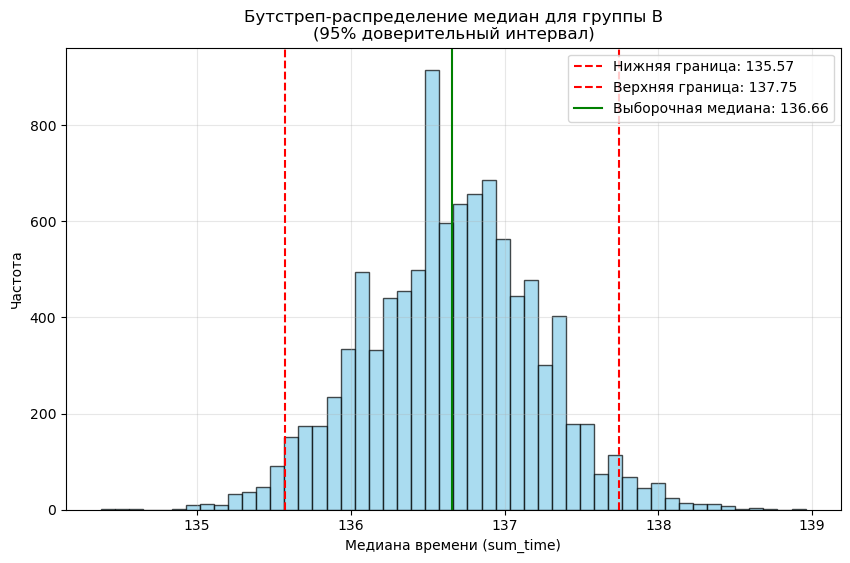

In [12]:
#делаем красиво, визуализируем
plt.figure(figsize=(10, 6))
plt.hist(result.bootstrap_distribution, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
plt.axvline(result.confidence_interval.low, color='red', linestyle='--', 
           label=f'Нижняя граница: {result.confidence_interval.low:.2f}')
plt.axvline(result.confidence_interval.high, color='red', linestyle='--', 
           label=f'Верхняя граница: {result.confidence_interval.high:.2f}')
plt.axvline(np.median(group_B), color='green', linestyle='-', 
           label=f'Выборочная медиана: {np.median(group_B):.2f}')
plt.xlabel('Медиана времени (sum_time)')
plt.ylabel('Частота')
plt.title('Бутстреп-распределение медиан для группы B\n(95% доверительный интервал)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
#Второй вопрос

#группы
group_a = data[data['group'] == 'A']['sum_time']
group_b = data[data['group'] == 'B']['sum_time']

def quantile_90(data):
    return np.quantile(data, 0.9)

n_resamples = 10000
confidence_level = 0.99
#для 99% доверительного интервала

result_a = bootstrap(
    (group_a,),
    quantile_90,
    confidence_level=confidence_level,
    n_resamples=n_resamples
)

result_b = bootstrap(
    (group_b,),
    quantile_90,
    confidence_level=confidence_level,
    n_resamples=n_resamples
)

diff_low = result_b.confidence_interval.low - result_a.confidence_interval.high
diff_high = result_b.confidence_interval.high - result_a.confidence_interval.low

print("90% квантиль для группы A:")
print(f"Нижняя граница: {result_a.confidence_interval.low:.2f}")
print(f"Верхняя граница: {result_a.confidence_interval.high:.2f}")

print("\n90% квантиль для группы B:")
print(f"Нижняя граница: {result_b.confidence_interval.low:.2f}")
print(f"Верхняя граница: {result_b.confidence_interval.high:.2f}")

print("\nРазница интервалов:")
print(f"Нижняя граница разницы: {diff_low:.2f}")
print(f"Верхняя граница разницы: {diff_high:.2f}")

90% квантиль для группы A:
Нижняя граница: 274.15
Верхняя граница: 282.47

90% квантиль для группы B:
Нижняя граница: 293.85
Верхняя граница: 302.85

Разница интервалов:
Нижняя граница разницы: 11.38
Верхняя граница разницы: 28.70


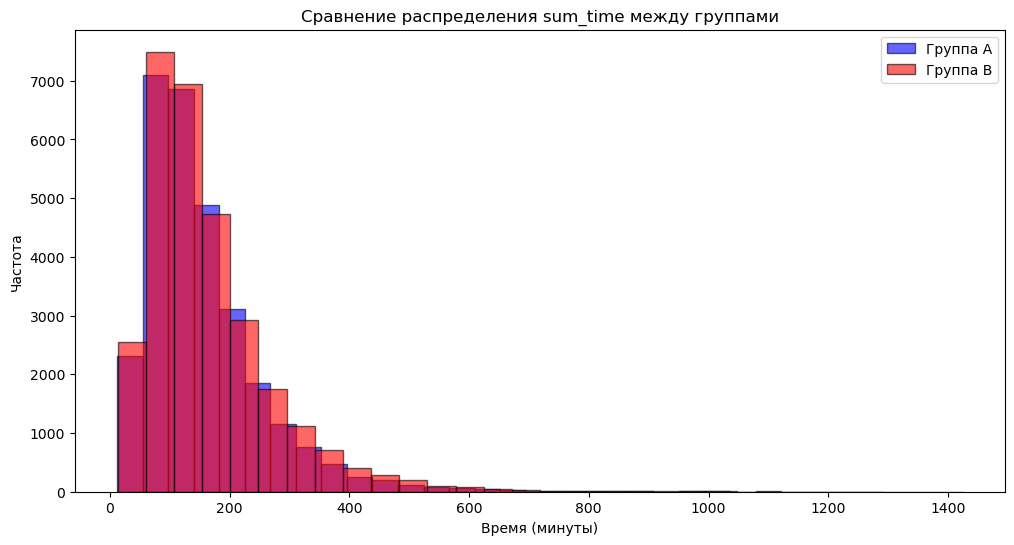

In [14]:
#визуализация
plt.figure(figsize=(12, 6))
plt.hist(group_a, bins=30, alpha=0.6, color='b', label='Группа A', edgecolor='black')
plt.hist(group_b, bins=30, alpha=0.6, color='r', label='Группа B', edgecolor='black')
plt.title('Сравнение распределения sum_time между группами')
plt.xlabel('Время (минуты)')
plt.ylabel('Частота')
plt.legend()
plt.show()

Квантили не перекрываются, значит, различие статистически значимо. Причём разница положительная: пользователи группы B тратят на верхнем уровне распределения (то есть среди самых долго сидящих 10% пользователей) на 11–28 минут больше, чем пользователи группы A. Тк доверительный интервал разницы не включает 0, при уровне значимости 1% (99% ДИ) можно утверждать, что различие действительно есть. Почему? Медиана (центральное значение) у групп действительно близка, что видно и на графике. Однако в «хвосте» распределения, где находятся самые активные пользователи, группа B тратит больше времени. Это может означать, что именно «самые активные» пользователи сильнее реагируют на изменения/условия в группе B